In [6]:
import cv2
import os
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from skimage.feature import hog
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


In [7]:
def load_images_folder_histogram(directory):

    data = []
    labels = []
    # Loading of all sub-folders in the directory
    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)

        # Getting path of image files one-by-one from a sub-folder 'subdir_path'
        if os.path.isdir(subdir_path):
            for filename in os.listdir(subdir_path):
                filepath = os.path.join(subdir_path, filename)

                # Checking whether obtained path is a filepath
                if os.path.isfile(filepath):

                    # Load and preprocess image (resize to uniform size)
                    image = cv2.imread(
                        filepath, cv2.IMREAD_GRAYSCALE
                    )  # Convert to grayscale using argument as cv2.IMREAD_GRAYSCALE

                    image = cv2.resize(image, (64, 64))  # Resize to 64x64 pixels

                    arr = (
                        image.flatten()
                    )  # flattening the image of size 64x64 to make one-dimentional array
                    arr1 = np.histogram(
                        arr, 10
                    )  # Computation of histogram of the array with 256 bins
                    # arr1 = [np.average(arr), np.max(arr), np.median(arr)]  #Other features

                    # data.append(image.flatten())  # Flatten the image

                    # Assigning suitable tables to different classes
                    data.append(arr1[0])
                    # if subdir == 'dogs':
                    #     labels.append(0)  # May use the folder name as the label
                    # else:
                    #     labels.append(1)
                    if subdir == "dogs":
                        labels.append(0)
                    elif subdir == "cats":
                        labels.append(1)
                    else:
                        labels.append(2)

    return np.array(data), np.array(labels)  # Convering results to Numpy arrays

In [8]:
def load_images_folder_mmm(directory):

    data = []
    labels = []
    # Loading of all sub-folders in the directory
    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)

    # Getting path of image files one-by-one from a sub-folder 'subdir_path'
        if os.path.isdir(subdir_path):
            for filename in os.listdir(subdir_path):
                filepath = os.path.join(subdir_path, filename)

                #Checking whether obtained path is a filepath
                if os.path.isfile(filepath):

                    # Load and preprocess image (resize to uniform size)
                    image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale using argument as cv2.IMREAD_GRAYSCALE

                    image = cv2.resize(image, (64, 64))  # Resize to 64x64 pixels

                    arr = image.flatten() #flattening the image of size 64x64 to make one-dimentional array
                    # arr1 = np.histogram(arr,10) #Computation of histogram of the array with 256 bins
                    arr1 = [np.average(arr), np.max(arr), np.median(arr)]  #Other features

                    # data.append(image.flatten())  # Flatten the image

                    #Assigning suitable tables to different classes
                    data.append(arr1)
                    # if subdir == 'dogs':
                    #     labels.append(0)  # May use the folder name as the label
                    # else:
                    #     labels.append(1)
                    if subdir == 'dogs':
                        labels.append(0)
                    elif subdir == 'cats':
                        labels.append(1)
                    else :labels.append(2)

    return np.array(data), np.array(labels)  #Convering results to Numpy arrays

In [9]:
def load_images_folder_gabor(directory):
    data = []
    labels = []

    # Gabor filter parameters
    ksize = 5  # Kernel size
    sigma = 1.0
    lambd = 10.0
    gamma = 0.5
    thetas = [0, 45, 90, 135]  # Orientations in degrees

    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)

        if os.path.isdir(subdir_path):
            for filename in os.listdir(subdir_path):
                filepath = os.path.join(subdir_path, filename)

                if os.path.isfile(filepath):
                    # Load and preprocess image
                    image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
                    image = cv2.resize(image, (64, 64))  # Resize to 64x64

                    gabor_features = []
                    for theta in thetas:
                        theta_rad = np.deg2rad(theta)
                        kernel = cv2.getGaborKernel((ksize, ksize), sigma, theta_rad, lambd, gamma, 0, ktype=cv2.CV_32F)
                        filtered_img = cv2.filter2D(image, cv2.CV_8UC3, kernel)  # Apply Gabor filter

                        gabor_features.append(np.mean(filtered_img))  # Mean response
                        gabor_features.append(np.var(filtered_img))   # Variance response

                    data.append(gabor_features)  # Store extracted features

                    # Assign class labels
                    # labels.append(0 if subdir == 'dogs' else 1)
                    if subdir == 'dogs':
                        labels.append(0)
                    elif subdir == 'cats':
                        labels.append(1)
                    else :labels.append(2)

    return np.array(data), np.array(labels)  # Convert to NumPy arrays

In [10]:
def load_images_folder_hog(directory):
    data = []
    labels = []

    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)

        if os.path.isdir(subdir_path):
            for filename in os.listdir(subdir_path):
                filepath = os.path.join(subdir_path, filename)

                if os.path.isfile(filepath):
                    # Load and preprocess image
                    image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
                    image = cv2.resize(image, (64, 64))  # Resize to 64x64

                    # Extract HOG features
                    hog_features = hog(image, orientations=9, pixels_per_cell=(8, 8),
                                       cells_per_block=(2, 2), block_norm='L2-Hys', feature_vector=True)

                    data.append(hog_features)  # Store extracted HOG features

                    # Assign class labels
                    # labels.append(0 if subdir == 'dogs' else 1)
                    if subdir == 'dogs':
                        labels.append(0)
                    elif subdir == 'cats':
                        labels.append(1)
                    else :labels.append(2)

    return np.array(data), np.array(labels)  # Convert to NumPy arrays

In [11]:
# Path to the dataset
dataset_directory1 = r"C:/D folder/Programming/programs/my codes/ML codes/knn classifier/Dog-Cat Dataset/train"
dataset_directory2 = r"C:/D folder/Programming/programs/my codes/ML codes/knn classifier/Dog-Cat Dataset/test"

# Load images and labels

images_train, labels_train = load_images_folder_histogram(dataset_directory1)
images_test, labels_test = load_images_folder_histogram(dataset_directory2)

# Normalize pixel values (0 to 1 scaling)
# scaler = StandardScaler()#z-score normalisation
# images_train = scaler.fit_transform(images_train)
# images_test = scaler.transform(images_test)


In [12]:

images_test.shape

(230, 10)

Best Accuracy: 43.48%
[[ 9 26 35]
 [10 28 32]
 [ 7 20 63]]
              precision    recall  f1-score   support

           0       0.35      0.13      0.19        70
           1       0.38      0.40      0.39        70
           2       0.48      0.70      0.57        90

    accuracy                           0.43       230
   macro avg       0.40      0.41      0.38       230
weighted avg       0.41      0.43      0.40       230



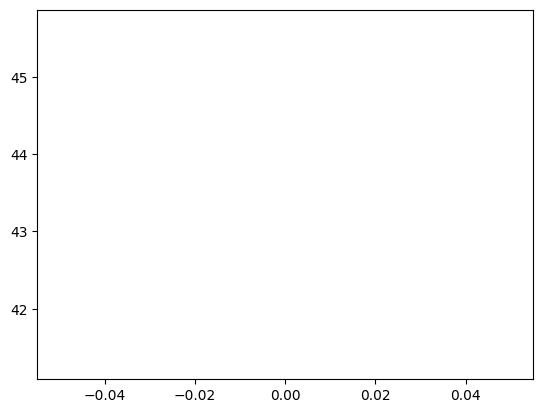

In [13]:
acc = []
# for i in np.arange(1, 100,2):
    # for j in np.arange(0.01, 1.1, 0.1):  # Tune gamma as well
# svm_linear  = SVC(kernel='linear', C=0.5)  # No extra params needed  
# svm_rbf     = SVC(kernel='rbf', C=0.5, gamma='scale')  # Gamma is important  
svm_poly    = SVC(kernel='poly', C=1.0, degree=3, gamma='scale')  # Degree & coef0 matter  
# svm_sigmoid = SVC(kernel='sigmoid', C=0.5, gamma='scale', coef0=0) 
svm_poly.fit(images_train, labels_train)
# Predict on the test set
y_pred = svm_poly.predict(images_test)
# Calculate accuracy
accuracy = accuracy_score(labels_test, y_pred)
acc.append(accuracy * 100)  # Store C and gamma value
# Find best combination
best_acc = max(acc)
print(f"Best Accuracy: {best_acc:.2f}%")
plt.plot(acc)

print(confusion_matrix(labels_test, y_pred))
print(classification_report(labels_test,y_pred))
#sensitivity, specificity, zscore,confusion matrix <-- like accuracy
# feature normalization
# C_values = np.arange(0.1, 10, 0.5)  # Range of C values
# acc = []

# best_accuracy = 0
# best_C = None
# best_model = None

# for C in C_values:
#     svm = SVC(kernel='linear', C=C)  # Linear Kernel
#     svm.fit(images_train, labels_train)
    
#     y_pred = svm.predict(images_test)
#     accuracy = accuracy_score(labels_test, y_pred)
    
#     acc.append(accuracy * 100)
    
#     if accuracy > best_accuracy:
#         best_accuracy = accuracy
#         best_C = C
#         best_model = svm

# # Print best accuracy and hyperparameters
# print(f"Best Accuracy: {best_accuracy * 100:.2f}% with C={best_C}")

# # Plot accuracy vs. C
# plt.plot(C_values, acc, marker='o')
# plt.xlabel("C Value")
# plt.ylabel("Accuracy (%)")
# plt.title("SVM Hyperparameter Tuning")
# plt.grid()
# plt.show()

# # Print Confusion Matrix and Classification Report
# best_y_pred = best_model.predict(images_test)
# print("Confusion Matrix:\n", confusion_matrix(labels_test, best_y_pred))
# print("Classification Report:\n", classification_report(labels_test, best_y_pred))